In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [4]:
data = pd.read_csv("/content/Raisin.csv")

In [5]:
features = data.iloc[:, :-1]
target = data.iloc[:, -1]

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(
    features, target, test_size=0.3, random_state=42
)

In [7]:
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

In [8]:
pca_model = PCA(n_components=4)
X_tr_pca = pca_model.fit_transform(X_tr_scaled)
X_te_pca = pca_model.transform(X_te_scaled)

In [9]:
classifier = LogisticRegression()
classifier.fit(X_tr_pca, y_tr)

predictions = classifier.predict(X_te_pca)

In [10]:
print("\n--- Classification Report ---")
print(classification_report(y_te, predictions))



--- Classification Report ---
              precision    recall  f1-score   support

       Besni       0.84      0.87      0.85       129
     Kecimen       0.88      0.84      0.86       141

    accuracy                           0.86       270
   macro avg       0.86      0.86      0.86       270
weighted avg       0.86      0.86      0.86       270



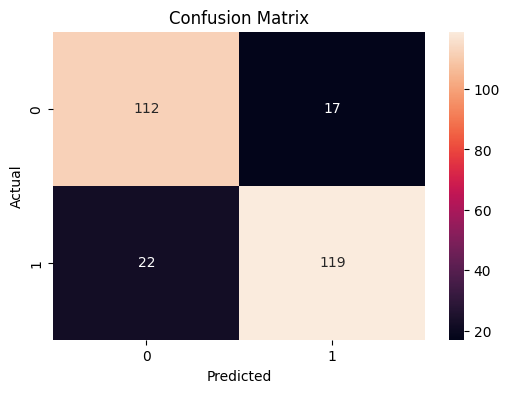

In [11]:
cm = confusion_matrix(y_te, predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
print("\n--- Performance Metrics ---")
print("Accuracy :", round(accuracy_score(y_te, predictions), 4))
print("Precision:", round(precision_score(y_te, predictions, average='weighted'), 4))
print("Recall   :", round(recall_score(y_te, predictions, average='weighted'), 4))
print("F1 Score :", round(f1_score(y_te, predictions, average='weighted'), 4))


--- Performance Metrics ---
Accuracy : 0.8556
Precision: 0.8563
Recall   : 0.8556
F1 Score : 0.8556


In [14]:
!pip install minisom
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=329efdac3712aa48f2c38320df40856b63fb78adbe89a6b313e8e2c06ba9a4c2
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


In [15]:
aqi_data = pd.read_csv("/content/aqi.csv")

In [16]:
cols = ['pm25', 'pm10', 'co', 'o3']
X = aqi_data[cols].to_numpy()

In [17]:
norm = MinMaxScaler()
X_norm = norm.fit_transform(X)

som_model = MiniSom(
    x=10, y=10,
    input_len=X_norm.shape[1],
    sigma=1.0,
    learning_rate=0.5
)


In [18]:
som_model.random_weights_init(X_norm)
som_model.train_random(X_norm, 1000)

In [19]:
q_err = som_model.quantization_error(X_norm)
t_err = som_model.topographic_error(X_norm)

print("\n--- SOM Metrics ---")
print(f"Quantization Error : {q_err:.4f}")
print(f"Topographic Error  : {t_err:.4f}")


--- SOM Metrics ---
Quantization Error : 0.0939
Topographic Error  : 0.4660


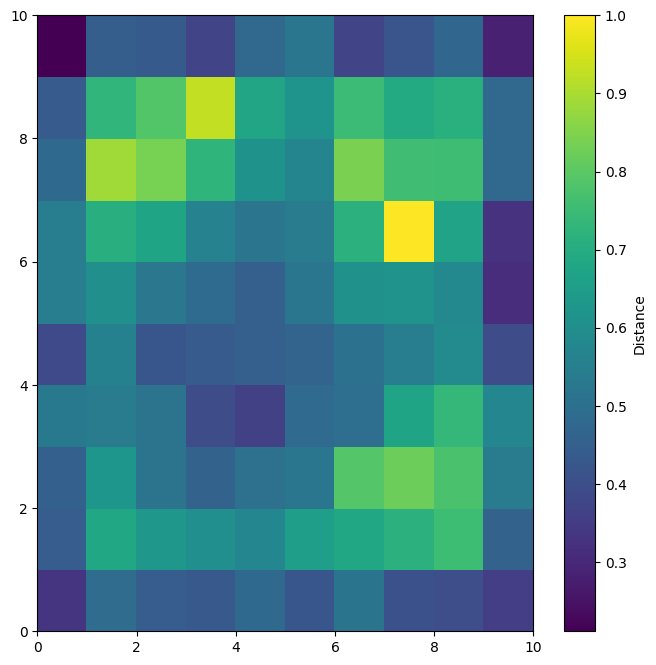

In [20]:
plt.figure(figsize=(8, 8))
plt.pcolor(som_model.distance_map().T)
plt.colorbar(label='Distance')

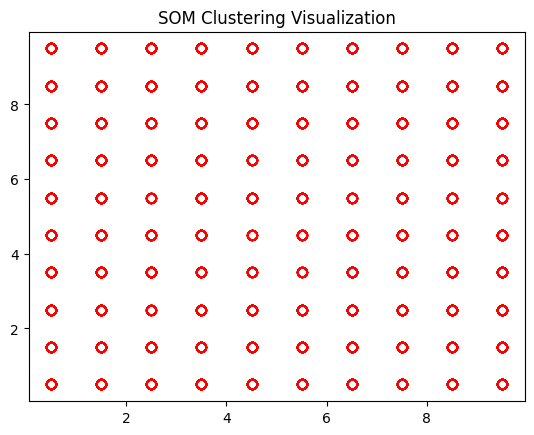

In [21]:
for i, val in enumerate(X_norm):
    win = som_model.winner(val)
    plt.plot(win[0] + 0.5, win[1] + 0.5, 'ro',
             markerfacecolor='None', markersize=7)

plt.title("SOM Clustering Visualization")
plt.show()